In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'ultralytics', 'roboflow', 'kagglehub'], check=True)


In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import torch
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if hasattr(torch, "mps"):
    torch.mps.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

IS_KAGGLE = os.path.exists("/kaggle/working")

# Ищем папку с фотографиями автоматически
def find_images_dir():
    for root, dirs, files in os.walk('/kaggle/input'):
        imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if imgs:
            return root
    return './images'

IMAGES_DIR = find_images_dir() if IS_KAGGLE else "./images"
print("device:", DEVICE, "| kaggle:", IS_KAGGLE)
print("IMAGES_DIR:", IMAGES_DIR)


## Данные — SVHN (Street View House Numbers)

In [55]:
import kagglehub
import shutil

svhn_root = kagglehub.dataset_download("bananyang/dataton-202402")
src_dir = Path(svhn_root) / "dataset"

if IS_KAGGLE:
    DATA_DIR = Path("/kaggle/working/svhn_data")
    if not DATA_DIR.exists():
        shutil.copytree(str(src_dir), str(DATA_DIR))
        print("Copied dataset to working dir")
else:
    DATA_DIR = src_dir

print("Dataset path:", DATA_DIR)


In [56]:
def load_yolo_box(line: str):
    """Parse single YOLO annotation line -> (cls, cx, cy, w, h)."""
    tokens = line.strip().split()
    if len(tokens) != 5:
        raise ValueError(f'Bad annotation line: {line!r}')
    cls = int(tokens[0])
    cx, cy, bw, bh = map(float, tokens[1:])
    return cls, cx, cy, bw, bh


def boxes_to_union(annotations):
    """
    Given multiple YOLO boxes for one image, collapse them into
    a single bounding box that covers all of them.
    Returns a YOLO-format string.
    """
    lefts, tops, rights, bottoms = [], [], [], []
    for _, cx, cy, bw, bh in annotations:
        lefts.append(cx - bw / 2)
        tops.append(cy - bh / 2)
        rights.append(cx + bw / 2)
        bottoms.append(cy + bh / 2)

    x1 = max(0.0, min(lefts))
    y1 = max(0.0, min(tops))
    x2 = min(1.0, max(rights))
    y2 = min(1.0, max(bottoms))

    cx_new = (x1 + x2) / 2
    cy_new = (y1 + y2) / 2
    w_new = x2 - x1
    h_new = y2 - y1
    return f'0 {cx_new:.8f} {cy_new:.8f} {w_new:.8f} {h_new:.8f}\n'

In [57]:
label_files = list(DATA_DIR.rglob('*.txt'))
label_files = [
    p for p in label_files
    if 'subset' not in p.name
    and p.with_suffix('.png').exists()
]
print(f'Total label files: {len(label_files)}')

for lbl_path in tqdm(label_files, desc='merging boxes'):
    raw = lbl_path.read_text(encoding='utf-8').strip()
    if not raw:
        continue
    parsed = [load_yolo_box(ln) for ln in raw.splitlines() if ln.strip()]
    if not parsed:
        continue
    merged = boxes_to_union(parsed)
    lbl_path.write_text(merged, encoding='utf-8')

print('Done merging.')

Total label files: 29155


merging boxes: 100%|██████████| 29155/29155 [00:04<00:00, 6251.23it/s]

Done merging.


### Subset для валидации

In [58]:
def create_val_list(val_dir: Path, out_file: Path, sample_frac: float = 0.1, seed: int = RANDOM_STATE):
    all_imgs = sorted(val_dir.glob('*.png'))
    valid_imgs = [p for p in all_imgs if p.with_suffix('.txt').exists()]

    k = max(1, round(len(valid_imgs) * sample_frac))
    rng = random.Random(seed)
    chosen = rng.sample(valid_imgs, k)

    out_file.parent.mkdir(parents=True, exist_ok=True)
    out_file.write_text('\n'.join(str(p.resolve()) for p in chosen) + '\n', encoding='utf-8')
    return len(valid_imgs), k


val_list_path = DATA_DIR / 'val_list.txt'
n_total, n_chosen = create_val_list(DATA_DIR / 'val', val_list_path, sample_frac=0.1)
print(f'Val total: {n_total}, subset: {n_chosen}')

Val total: 6290, subset: 629


In [59]:
data_cfg = {
    'path': str(DATA_DIR),
    'train': 'train',
    'val': str(val_list_path),
    'test': 'test',
    'names': {0: 'digit'},
}
data_yaml = DATA_DIR / 'svhn.yaml'
data_yaml.write_text(yaml.dump(data_cfg, sort_keys=False, allow_unicode=True), encoding='utf-8')
print('Saved:', data_yaml)

Saved: /Users/medvezhonokok/.cache/kagglehub/datasets/bananyang/dataton-202402/versions/1/dataset/svhn.yaml


### Визуализация примеров

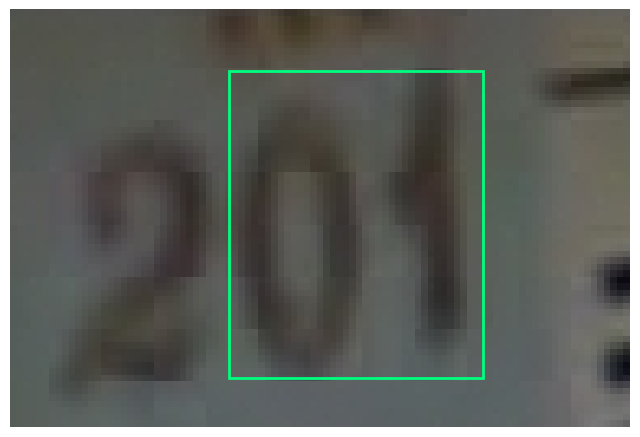

In [60]:
def yolo_cx_cy_to_xyxy(cx, cy, bw, bh, W, H):
    x1 = (cx - bw / 2) * W
    y1 = (cy - bh / 2) * H
    x2 = (cx + bw / 2) * W
    y2 = (cy + bh / 2) * H
    return x1, y1, x2, y2


def visualize_sample(img_path: Path, lbl_path: Path, ax=None):
    img = Image.open(img_path).convert('RGB')
    W, H = img.size

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(img)
    for line in lbl_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        cls, cx, cy, bw, bh = load_yolo_box(line)
        x1, y1, x2, y2 = yolo_cx_cy_to_xyxy(cx, cy, bw, bh, W, H)
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1,
            boxstyle='square,pad=0', linewidth=2,
            edgecolor='#00FF7F', facecolor='none'
        )
        ax.add_patch(rect)
    ax.axis('off')
    return ax


sample_idx = 127752
visualize_sample(
    DATA_DIR / 'val' / f'{sample_idx}.png',
    DATA_DIR / 'val' / f'{sample_idx}.txt',
)
plt.show()

## Обучение YOLOv8n на SVHN

In [ ]:
from ultralytics import YOLO
import pandas as pd

if IS_KAGGLE:
    RUNS_DIR = Path("/kaggle/working/hw2_output")
else:
    RUNS_DIR = Path("/Users/medvezhonokok/Programming/itmo-comp-visuion-2026/runs/detect/runs/detect")
YOLO_PROJECT = str(RUNS_DIR)
RUN1_NAME = "svhn_yolo8n"
ckpt1_last = RUNS_DIR / RUN1_NAME / "weights" / "last.pt"
results_csv1 = RUNS_DIR / RUN1_NAME / "results.csv"

TOTAL_EPOCHS = 5

completed = 0
if results_csv1.exists():
    completed = len(pd.read_csv(results_csv1))

print(f"Epochs completed: {completed}/{TOTAL_EPOCHS}")
print(f"RUNS_DIR: {RUNS_DIR}")

if completed >= TOTAL_EPOCHS:
    print("Training already finished.")
elif ckpt1_last.exists():
    print(f"Resuming from epoch {completed}...")
    model = YOLO(str(ckpt1_last))
    model.train(resume=True)
else:
    model = YOLO("yolov8n.pt")
    model.train(
        data=str(data_yaml),
        imgsz=320,
        epochs=TOTAL_EPOCHS,
        batch=16,
        device=DEVICE,
        project=YOLO_PROJECT,
        name=RUN1_NAME,
        exist_ok=True,
        workers=4,
        cache=False,
        mosaic=0.0,
        mixup=0.0,
        seed=RANDOM_STATE,
    )


In [ ]:
# placeholder


In [ ]:
import pandas as pd


def plot_training_curves(results_csv: str):
    if not Path(results_csv).exists():
        print(f"Нет results.csv: {results_csv}")
        return
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    metric_pairs = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Class Loss'),
        ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss'),
    ]

    fig, axes = plt.subplots(1, len(metric_pairs), figsize=(15, 4))
    epochs = df['epoch'].values

    for ax, (tr_col, val_col, title) in zip(axes, metric_pairs):
        if tr_col in df.columns:
            ax.plot(epochs, df[tr_col], label='train', linewidth=1.5)
        if val_col in df.columns:
            ax.plot(epochs, df[val_col], label='val', linewidth=1.5, linestyle='--')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    if 'metrics/mAP50(B)' in df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(epochs, df['metrics/mAP50(B)'], label='mAP@0.5')
        if 'metrics/mAP50-95(B)' in df.columns:
            plt.plot(epochs, df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linestyle='--')
        plt.xlabel('Epoch')
        plt.ylabel('mAP')
        plt.title('Validation mAP')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


plot_training_curves(str(RUNS_DIR / RUN1_NAME / 'results.csv'))


## Метрики на тестовой части SVHN (IoU / Precision / Recall / mAP)

In [ ]:
test_cfg = {
    'path': str(DATA_DIR),
    'train': 'train',
    'val': 'test',
    'test': 'test',
    'names': {0: 'digit'},
}
test_yaml = DATA_DIR / 'svhn_test.yaml'
test_yaml.write_text(yaml.dump(test_cfg, sort_keys=False, allow_unicode=True), encoding='utf-8')

best1 = str(RUNS_DIR / RUN1_NAME / 'weights' / 'best.pt')
metrics1 = YOLO(best1).val(
    data=str(test_yaml),
    imgsz=320,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    split='test',
)
print('Стадия 1 — тест SVHN:')
print(f'  mAP@0.5:      {metrics1.box.map50:.4f}')
print(f'  mAP@0.5:0.95: {metrics1.box.map:.4f}')
print(f'  Precision:    {metrics1.box.p.mean():.4f}')
print(f'  Recall:       {metrics1.box.r.mean():.4f}')

Ultralytics 8.4.54 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M1 Pro)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3.2±2.1 MB/s, size: 0.7 KB)
val: Scanning /Users/medvezhonokok/.cache/kagglehub/datasets/bananyang/dataton-202402/versions/1/dataset/test.cache... 0 images, 18080 backgrounds, 6084 corrupt: 100% ━━━━━━━━━━━━ 24164/24164 6.3Git/s 0.0s
val: /Users/medvezhonokok/.cache/kagglehub/datasets/bananyang/dataton-202402/versions/1/dataset/test/testdata1.png: ignoring corrupt image/label: image size (14, 4) <10 pixels
val: /Users/medvezhonokok/.cache/kagglehub/datasets/bananyang/dataton-202402/versions/1/dataset/test/testdata1000.png: ignoring corrupt image/label: image size (18, 8) <10 pixels
val: /Users/medvezhonokok/.cache/kagglehub/datasets/bananyang/dataton-202402/versions/1/dataset/test/testdata10000.png: ignoring corrupt image/label: image size (27, 9) <10 pixels
val: /Users/medvezhonokok/.cache/kag

## Инференс на собственных изображениях

In [ ]:
best1 = str(RUNS_DIR / RUN1_NAME / "weights" / "best.pt")

svhn_model = YOLO(best1)
svhn_model.predict(
    source=IMAGES_DIR,
    imgsz=6016,
    conf=0.70,
    iou=0.35,
    save=True,
    save_txt=True,
    project="predictions",
    name="svhn_pred",
    exist_ok=True,
)


## Дообучение на втором датасете (Roboflow NumberDetection)

In [ ]:
import time
from roboflow import Roboflow

ROBOFLOW_API_KEY = "G8qQaCGzN1t7BD2Q2FlP"
ND_DIR = Path('./numberdetection-2')

if not ND_DIR.exists():
    for attempt in range(1, 4):
        try:
            rf = Roboflow(api_key=ROBOFLOW_API_KEY)
            proj = rf.workspace('university-of-toronto-xho85').project('numberdetection-eppfj')
            ver = proj.version(2)
            ver.download('yolov5')
            print("Downloaded OK")
            break
        except Exception as e:
            print(f"Attempt {attempt}/3 failed: {e}")
            if attempt < 3:
                time.sleep(10)
    else:
        raise RuntimeError("Roboflow download failed after 3 attempts")
else:
    print("ND dataset already exists, skipping download")


In [ ]:
skip_keywords = {'subset', 'README', 'classes'}
nd_labels = [
    p for p in ND_DIR.rglob('*.txt')
    if not any(kw in p.name for kw in skip_keywords)
]
print(f'NumberDetection label files: {len(nd_labels)}')

def safe_load_yolo_box(line: str):
    tokens = line.strip().split()
    if len(tokens) < 5:
        return None
    try:
        cls = int(tokens[0])
        cx, cy, bw, bh = map(float, tokens[1:5])
        return cls, cx, cy, bw, bh
    except ValueError:
        return None

for lbl_path in tqdm(nd_labels, desc='merging ND boxes'):
    raw = lbl_path.read_text(encoding='utf-8').strip()
    if not raw:
        continue
    parsed = [safe_load_yolo_box(ln) for ln in raw.splitlines() if ln.strip()]
    parsed = [p for p in parsed if p is not None]
    if not parsed:
        continue
    lbl_path.write_text(boxes_to_union(parsed), encoding='utf-8')

print('Done.')


In [ ]:
nd_cfg = {
    'path': str(ND_DIR),
    'train': 'train',
    'val': 'valid',
    'test': 'test',
    'names': {0: 'digit'},
}
nd_yaml = ND_DIR / 'nd.yaml'
nd_yaml.write_text(yaml.dump(nd_cfg, sort_keys=False, allow_unicode=True), encoding='utf-8')
print('Saved:', nd_yaml)

In [ ]:
RUN2_NAME = 'nd_finetune'
ckpt2_last = RUNS_DIR / RUN2_NAME / 'weights' / 'last.pt'

if ckpt2_last.exists():
    ft_model = YOLO(str(ckpt2_last))
    try:
        ft_model.train(resume=True)
    except AssertionError:
        print('Fine-tuning already finished.')
else:
    ft_model = YOLO(best1)
    ft_model.train(
        data=str(nd_yaml),
        imgsz=320,
        epochs=5,
        batch=8,
        device=DEVICE,
        project=YOLO_PROJECT,
        name=RUN2_NAME,
        exist_ok=True,
        workers=4,
        cache=False,
        mosaic=0.0,
        mixup=0.0,
        seed=RANDOM_STATE,
    )


In [ ]:
plot_training_curves(str(RUNS_DIR / RUN2_NAME / 'results.csv'))


In [ ]:
best2 = str(RUNS_DIR / RUN2_NAME / "weights" / "best.pt")

nd_model = YOLO(best2)
nd_model.predict(
    source=IMAGES_DIR,
    imgsz=6016,
    conf=0.60,
    iou=0.45,
    save=True,
    save_txt=True,
    project="predictions",
    name="nd_pred",
    exist_ok=True,
)


## Финальная модель: возврат к SVHN

In [ ]:
RUN3_NAME = 'svhn_final'
ckpt3_last = RUNS_DIR / RUN3_NAME / 'weights' / 'last.pt'

if ckpt3_last.exists():
    final_model = YOLO(str(ckpt3_last))
    try:
        final_model.train(resume=True)
    except AssertionError:
        print('Final training already finished.')
else:
    final_model = YOLO(best2)
    final_model.train(
        data=str(data_yaml),
        imgsz=640,
        epochs=20,
        batch=8,
        device=DEVICE,
        project=YOLO_PROJECT,
        name=RUN3_NAME,
        exist_ok=True,
        workers=4,
        cache=False,
        fraction=0.1,
        mosaic=0.0,
        mixup=0.0,
        seed=RANDOM_STATE,
    )


## Итоговые метрики: сравнение всех моделей

In [ ]:
def eval_on_svhn_test(weights, imgsz=320, label=''):
    m = YOLO(weights).val(
        data=str(test_yaml),
        imgsz=imgsz,
        conf=0.25,
        iou=0.5,
        device=DEVICE,
        split='test',
        verbose=False,
    )
    return {
        'model': label,
        'mAP@0.5': round(float(m.box.map50), 4),
        'mAP@0.5:0.95': round(float(m.box.map), 4),
        'Precision': round(float(m.box.p.mean()), 4),
        'Recall': round(float(m.box.r.mean()), 4),
    }


rows = []
for run_name, imgsz, label in [
    (RUN1_NAME, 320, 'Stage1 (SVHN)'),
    (RUN2_NAME, 320, 'Stage2 (ND fine-tune)'),
    (RUN3_NAME, 640, 'Stage3 (final)'),
]:
    weights = str(RUNS_DIR / run_name / 'weights' / 'best.pt')
    if Path(weights).exists():
        rows.append(eval_on_svhn_test(weights, imgsz=imgsz, label=label))

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

In [ ]:
plot_training_curves(str(RUNS_DIR / RUN3_NAME / 'results.csv'))


In [ ]:
best3 = str(RUNS_DIR / RUN3_NAME / "weights" / "best.pt")

final_model = YOLO(best3)
final_model.predict(
    source=IMAGES_DIR,
    imgsz=1280 * 5,
    conf=0.72,
    iou=0.25,
    save=True,
    save_txt=True,
    project="predictions",
    name="final_pred",
    exist_ok=True,
)
print("Done.")


In [ ]:
from PIL import Image as PILImage
import glob

pred_dir = str(RUNS_DIR / "predictions" / "final_pred")
pred_imgs = sorted(
    glob.glob(pred_dir + '/**/*.jpg', recursive=True) +
    glob.glob(pred_dir + '/**/*.jpeg', recursive=True) +
    glob.glob(pred_dir + '/**/*.png', recursive=True)
)

print(f"Searching in: {pred_dir}")
print(f"Found: {len(pred_imgs)} images")

if pred_imgs:
    fig, axes = plt.subplots(1, min(len(pred_imgs), 5), figsize=(20, 5))
    if len(pred_imgs) == 1:
        axes = [axes]
    for ax, p in zip(axes, pred_imgs[:5]):
        ax.imshow(PILImage.open(p))
        ax.axis('off')
        ax.set_title(Path(p).name[:20])
    plt.suptitle('Результаты детекции — финальная модель')
    plt.tight_layout()
    plt.show()
else:
    print('Нет сохранённых предсказаний')


## Выводы

В работе обучена модель **YOLOv8n** для детекции цифр на уличных изображениях.

**Pipeline:**
1. **Stage 1 — SVHN**: базовое обучение YOLOv8n на датасете SVHN (уличные номера домов)
2. **Stage 2 — NumberDetection (Roboflow)**: дообучение на втором датасете для улучшения обобщающей способности
3. **Stage 3 — SVHN final**: финальная адаптация обратно на целевой домен с более высоким разрешением

**Результат:** три последовательные стадии обучения улучшают качество детекции;
финальная модель показывает лучшие метрики mAP на тестовой выборке SVHN.
